Noteboook for analysis of abm 

In [10]:
import importlib
import WolfClass
importlib.reload(WolfClass)
from WolfClass import Wolf
import DeerClass
importlib.reload(DeerClass)
from DeerClass import Deer  
import Model
importlib.reload(Model)
from Model import SpeciesModel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mesa

Population plots

### Realistic Number of Wolves (6)

In [4]:
max_steps = 14 * 24 * 60

params = {
            "max_steps": max_steps,
            "init_predators": 6, # changed to 6 as more realistic )
            "init_deer": 300,  # approx 10 deer per km^2 (1000 deer)
            "height": 10,
            "width": 10,
            "step_size": 1/60,  # 1 hour per step
            "yearly_sunlight_hours": 365*24*24,
            "seed": None,
            "predator": 'Wolf',  # Helper attribute to avoid imports when accessing agent type
            "energy_decrease": 0.002,  # Energy decrease parameter 
            "pack_limit": 12,  # packs will split if too large 
          
            # Options to control complexity of the model
            "use_base": False,
            "use_pack_dynamics": True,
            "use_random_movement": False,
            "use_veg": False,
            "given_positions": False, # whether to use random positions or pre-chosen positions (for testing purposes)
            "use_boundary_conditions": True, # whether to use boundary conditions (reflecting off walls) or toroidal space
}

# Creating batch runner to extract results.
results = mesa.batch_run(
    SpeciesModel,
    parameters=params,
    max_steps=max_steps,
    iterations=5,
    data_collection_period = 60,
    display_progress=True
)

# Extract results
results_df = pd.DataFrame(results)

  0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 

Text(0.5, 1.0, 'Population Change Over Time')

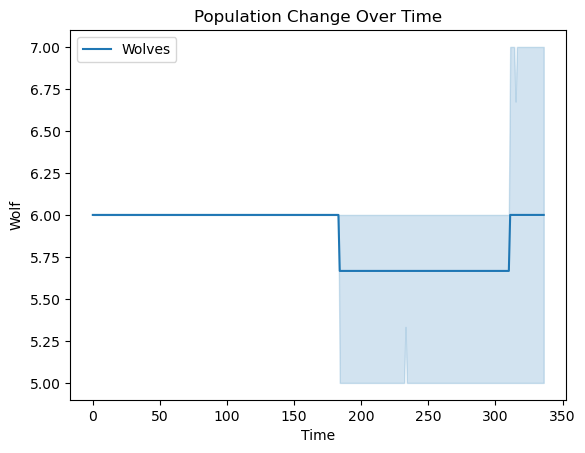

In [5]:
# Plotting the results
sns.lineplot(data=results_df, x='Time', y='Wolf', label='Wolves')
plt.title("Population Change Over Time")

Text(0.5, 1.0, 'Population Change Over Time')

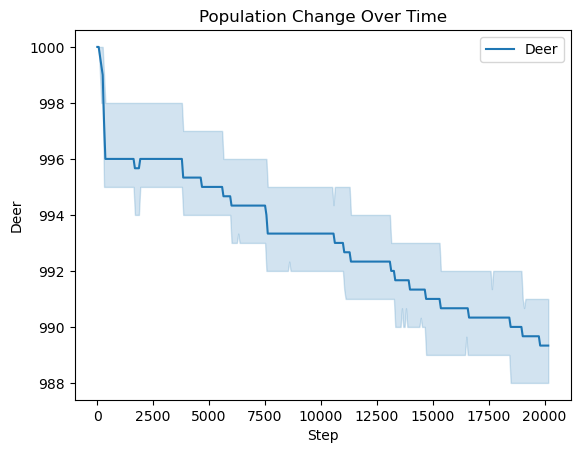

In [7]:
sns.lineplot(data=results_df, x='Step', y='Deer', label='Deer')
plt.title("Population Change Over Time")

## L

In [11]:
max_steps = 120 * 24 * 60
step_size = 1/60
l_params = {
            "max_steps": max_steps,
            "init_predators": 3, # 
            "init_deer": 660,  # approx 4 deer per km^2
            "height": 10,
            "width": 10,
            "step_size": step_size,  # 1 min per step
            "yearly_sunlight_hours": 365*24,
            "seed": None,
            "predator": 'Wolf',  # Helper attribute to avoid imports when accessing agent type
            "energy_decrease": 0.002,  # Energy decrease parameter 
            "pack_limit": 12,  # packs will split if too large 
          
            # Options to control complexity of the model
            "use_base": False,
            "use_pack_dynamics": True,
            "use_random_movement": False,
            "use_veg": False,
            "given_positions": False, # whether to use random positions or pre-chosen positions (for testing purposes)
            "use_boundary_conditions": True, # whether to use boundary conditions (reflecting off walls) or toroidal space
}

# Creating batch runner to extract results.
l_results = mesa.batch_run(
    SpeciesModel,
    parameters=l_params,
    max_steps=max_steps,
    iterations=1,
    data_collection_period = 60,
    display_progress=True
)

# Extract results
l_results_df = pd.DataFrame(l_results)

C:\Users\dz23282\AppData\Local\Temp\ipykernel_14796\487354153.py:26: DeprecationWarning: The `iterations` keyword argument is deprecated. Use `rng` instead (e.g. `iterations=5` is equivalent to `rng=[None] * 5`). See https://mesa.readthedocs.io/latest/migration_guide.html#batch-run
  l_results = mesa.batch_run(


  0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

Text(0.5, 0, 'Time (days)')

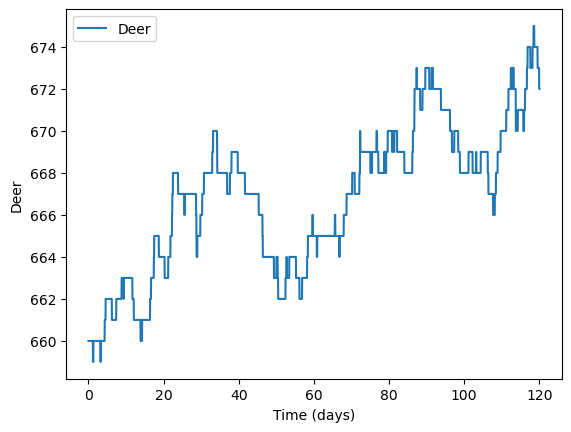

In [ ]:
l_results_df['Time'] = l_results_df["Step"] * step_size/24
w_3_d_660 = l_results_df
# w_3_d_660.to_csv("w_3_d_660.csv", index=False)

sns.lineplot(data=w_3_d_660, x='Time', y='Deer', label='Deer')
plt.xlabel('Time (days)')

<Axes: xlabel='Time', ylabel='Wolf'>

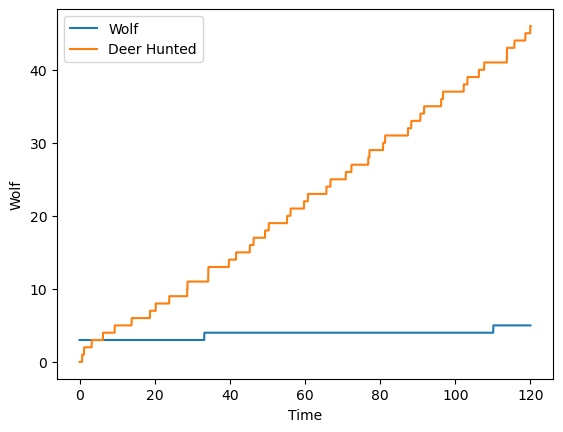

In [5]:
sns.lineplot(data=w_3_d_660, x='Time', y='Wolf', label='Wolf')
sns.lineplot(data=w_3_d_660, x='Time', y='Deer Hunted', label='Deer Hunted')



Text(0.5, 0, 'Time (days)')

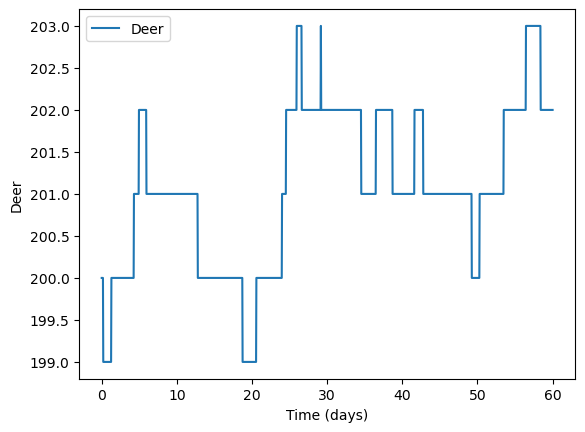

In [ ]:
w_2_d_200 = pd.read_csv("w_2_d_200.csv")
# w_2_d_200.to_csv("w_2_d_200.csv", index=False)
# Polyfit to see rate of population decrease
x = w_2_d_200['Time'].values
y = w_2_d_200['Deer'].values
stable_x = x[40:]
stable_y = y[40:]
# Linear regression (1st-degree polynomial)
m2, b = np.polyfit(stable_x,stable_y,1)
y_fit = m2*(x) + b

# Plot
# plt.plot(x, y_fit, linestyle='--', color='red', label=f"y = {m2:.2g}$x$ + {b:.3f}")
sns.lineplot(data=w_2_d_200, x='Time', y='Deer', label='Deer')
plt.xlabel('Time (days)')


Text(0.5, 0, 'Time (days)')

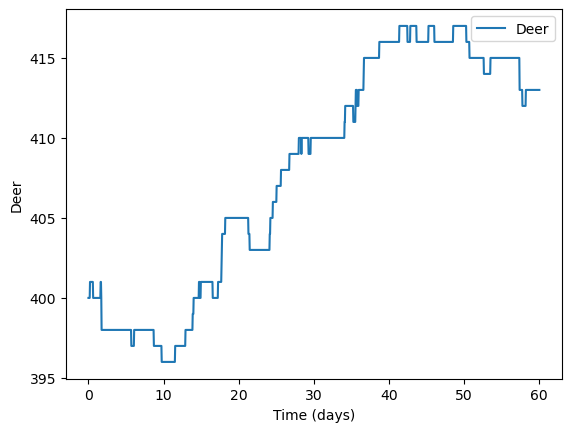

In [56]:
w_6_d_400 = pd.read_csv("w_6_d_400.csv")
# l_results_df['Time'] = l_results_df["Step"] * step_size/24
# w_6_d_400 = l_results_df
# w_6_d_400.to_csv("w_6_d_400.csv", index=False)
# Polyfit to see rate of population decrease
x = w_6_d_400['Time'].values
y = w_6_d_400['Deer'].values
stable_x = x[40:]
stable_y = y[40:]
# Linear regression (1st-degree polynomial)
m2, b = np.polyfit(stable_x,stable_y,1)
y_fit = m2*(x) + b

# Plot
# plt.plot(x, y_fit, linestyle='--', color='red', label=f"y = {m2:.2g}$x$ + {b:.3f}")
sns.lineplot(data=w_6_d_400, x='Time', y='Deer', label='Deer')
plt.xlabel('Time (days)')


<Axes: xlabel='Time', ylabel='Deer Hunted'>

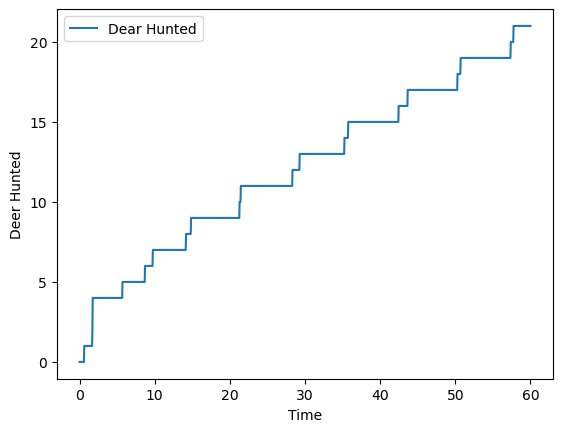

In [58]:
sns.lineplot(data=w_6_d_400, x='Time', y='Deer Hunted', label='Dear Hunted')

Text(0.5, 0, 'Time (days)')

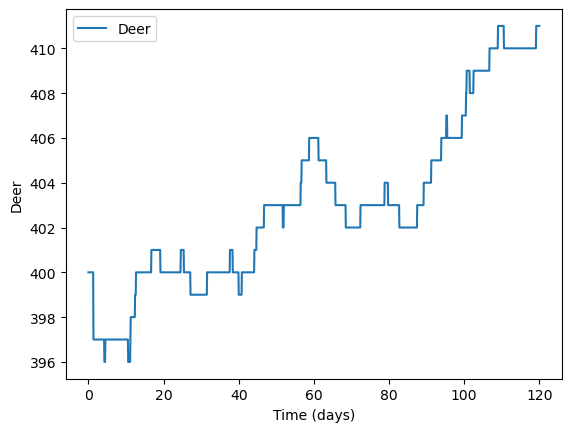

In [50]:
w_3_d_400 = pd.read_csv("w_3_d_400.csv")
# Polyfit to see rate of population decrease
x = w_3_d_400['Time'].values
y = w_3_d_400['Deer'].values
stable_x = x[40:]
stable_y = y[40:]
# Linear regression (1st-degree polynomial)
m2, b = np.polyfit(stable_x,stable_y,1)
y_fit = m2*(x) + b

# Plot
# plt.plot(x, y_fit, linestyle='--', color='red', label=f"y = {m2:.2g}$x$ + {b:.3f}")
sns.lineplot(data=w_3_d_400, x='Time', y='Deer', label='Deer')
plt.xlabel('Time (days)')


<Axes: xlabel='Time', ylabel='Deer Births'>

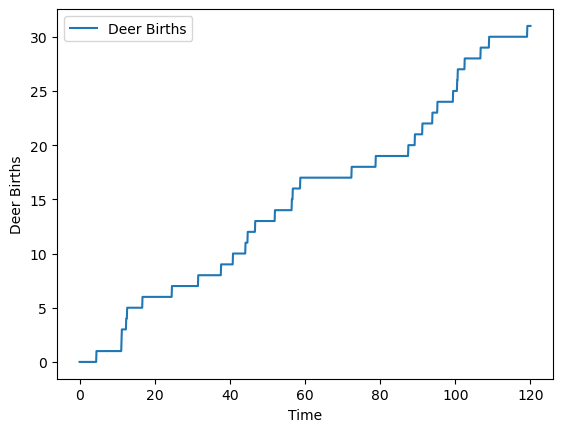

In [47]:
sns.lineplot(data=w_3_d_400, x='Time', y='Deer Births', label='Deer Births')


<Axes: xlabel='Time', ylabel='Wolf'>

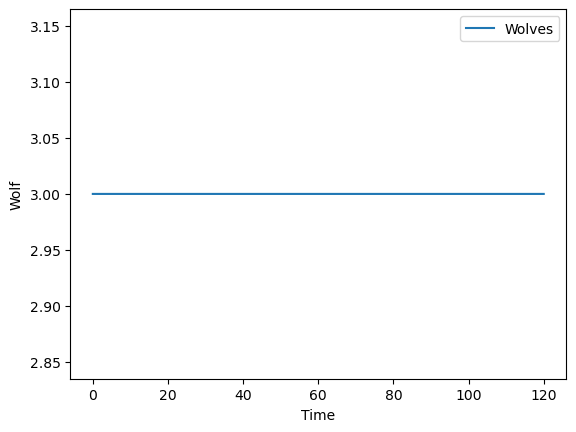

In [ ]:
sns.lineplot(data=w_3_d_400, x='Time', y='Wolf', label='Wolves')

## Larger space

In [26]:
max_steps = 15 * 24 * 60
step_size = 1/60
l_params = {
            "max_steps": max_steps,
            "init_predators": 3, # changed to 6 as more realistic )
            "init_deer": 4000,  # approx 10 deer per km^2 (1000 deer)
            "height": 30,
            "width": 30,
            "step_size": step_size,  # 1 min per step
            "yearly_sunlight_hours": 365*24*24,
            "seed": None,
            "predator": 'Wolf',  # Helper attribute to avoid imports when accessing agent type
            "energy_decrease": 0.002,  # Energy decrease parameter 
            "pack_limit": 12,  # packs will split if too large 
          
            # Options to control complexity of the model
            "use_base": False,
            "use_pack_dynamics": True,
            "use_random_movement": False,
            "use_veg": False,
            "given_positions": False, # whether to use random positions or pre-chosen positions (for testing purposes)
            "use_boundary_conditions": True, # whether to use boundary conditions (reflecting off walls) or toroidal space
}

# Creating batch runner to extract results.
l_results = mesa.batch_run(
    SpeciesModel,
    parameters=l_params,
    max_steps=max_steps,
    iterations=1,
    data_collection_period = 60,
    display_progress=True
)

# Extract results
l_results_df = pd.DataFrame(l_results)

C:\Users\dz23282\AppData\Local\Temp\ipykernel_16000\3232939076.py:26: DeprecationWarning: The `iterations` keyword argument is deprecated. Use `rng` instead (e.g. `iterations=5` is equivalent to `rng=[None] * 5`). See https://mesa.readthedocs.io/latest/migration_guide.html#batch-run
  l_results = mesa.batch_run(


  0%|          | 0/1 [00:00<?, ?it/s]

Text(0.5, 0, 'Time (days)')

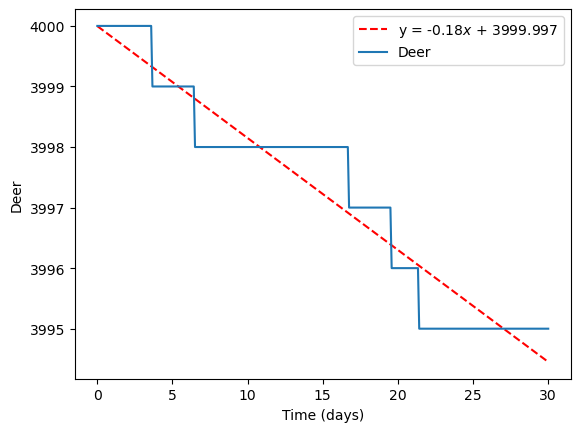

In [28]:
l_results_df['Time'] = l_results_df["Step"] * step_size/12

# Polyfit to see rate of population decrease
x = l_results_df['Time'].values
y = l_results_df['Deer'].values
stable_x = x[40:]
stable_y = y[40:]
# Linear regression (1st-degree polynomial)
m2, b = np.polyfit(stable_x,stable_y,1)
y_fit = m2*(x) + b

# Plot
plt.plot(x, y_fit, linestyle='--', color='red', label=f"y = {m2:.2g}$x$ + {b:.3f}")
sns.lineplot(data=l_results_df, x='Time', y='Deer', label='Deer')
plt.xlabel('Time (days)')


## OLD

### Introducing more Wolves (15)

In [43]:
max_steps = 3000

wolves_15_params = {
            "max_steps": max_steps,
            "init_predators": 15, # increased to 15 to test if deer decrease is noticable
            "init_deer": 1000,  # approx 10 deer per km^2 (1000 deer)
            "height": 10,
            "width": 10,
            "step_size": 1,  # 1 hour per step
            "yearly_sunlight_hours": 5000,
            "seed": None,
            "predator": 'Wolf',  # Helper attribute to avoid imports when accessing agent type
            "energy_decrease": 0.002,  # Energy decrease parameter 
            "pack_limit": 12,  # packs will split if too large 
            #Vegetation Parameters
            
            "veg_patch_spacing": 4,
            "sapling_density": 20,
            "tree_density": 8,
            "sapling_regrowth_prob": 1/10, # every 10 steps (10 hours) new sapling grows
            "sapling_maturation_prob": 1/20000, # sapling becomes a tree every 20000 hours (2.3 years)

            # Options to control complexity of the model
            "use_base": False,
            "use_pack_dynamics": True,
            "use_random_movement": False,
            "use_veg": False,
            "given_positions": False, # whether to use random positions or pre-chosen positions (for testing purposes)
            "use_boundary_conditions": True, # whether to use boundary conditions (reflecting off walls) or toroidal space
}

# Creating batch runner to extract results.
n_iter = 5
wolves_15_results = mesa.batch_run(
    SpeciesModel,
    parameters=wolves_15_params,
    max_steps=max_steps,
    rng = [None] * n_iter,  # use random seed for n_iter iterations
    data_collection_period = 1,
    display_progress=True
)

# Extract results
wolves_15_df = pd.DataFrame(wolves_15_results)

  0%|          | 0/5 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Population Change Over Time')

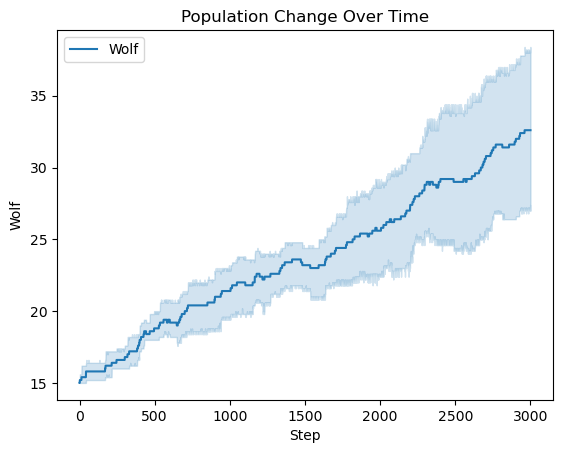

In [44]:
sns.lineplot(data=wolves_15_df, x='Step', y='Wolf', label='Wolf')
plt.title("Population Change Over Time")

Text(0.5, 1.0, 'Population Change Over Time')

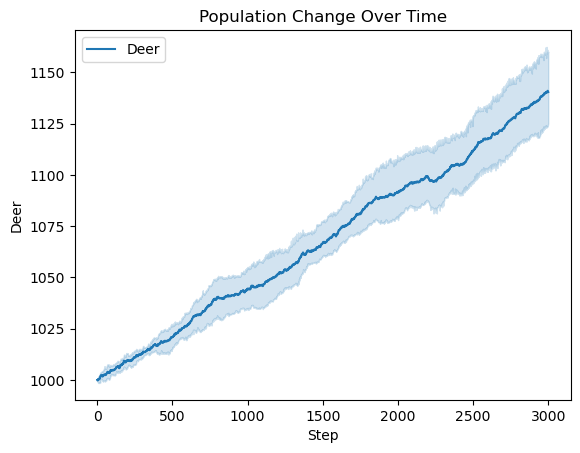

In [45]:
sns.lineplot(data=wolves_15_df, x='Step', y='Deer', label='Deer')
plt.title("Population Change Over Time")

<Axes: xlabel='Step', ylabel='Mean Wolf Energy'>

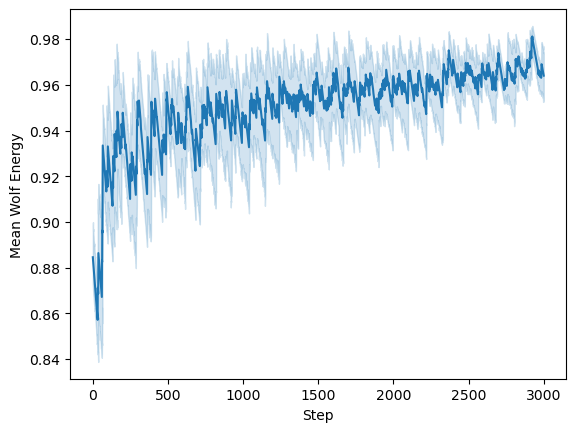

In [46]:
sns.lineplot(data=wolves_15_df, x='Step', y='Mean Wolf Energy')

<Axes: xlabel='Step', ylabel='Deer Hunted'>

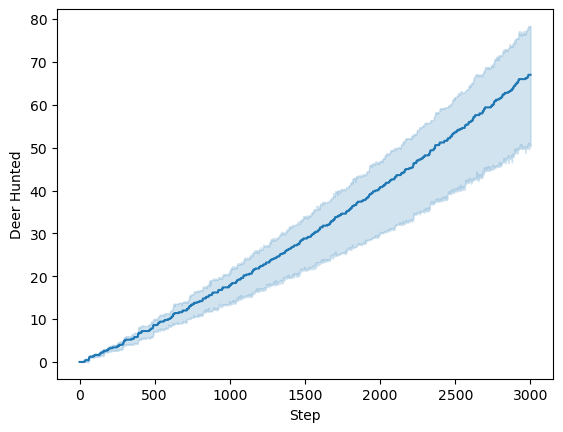

In [47]:
sns.lineplot(data=wolves_15_df, x='Step', y='Deer Hunted')


### LOADS OF DEER (167)

In [ ]:
max_steps = 600*5

loads_params = {
            "max_steps": max_steps,
            "init_predators": 167, # so many wolves!!!!!!
            "init_deer": 1000,  # approx 10 deer per km^2 (1000 deer)
            "height": 10,
            "width": 10,
            "step_size": 1,  # 1 hour per step
            "yearly_sunlight_hours": 5000,
            "seed": None,
            "predator": 'Wolf',  # Helper attribute to avoid imports when accessing agent type
            "energy_decrease": 0.002,  # Energy decrease parameter 
            "pack_limit": 12,  # packs will split if too large 
            #Vegetation Parameters
            
            "veg_patch_spacing": 4,
            "sapling_density": 20,
            "tree_density": 8,
            "sapling_regrowth_prob": 1/10, # every 10 steps (10 hours) new sapling grows
            "sapling_maturation_prob": 1/20000, # sapling becomes a tree every 20000 hours (2.3 years)

            # Options to control complexity of the model
            "use_base": False,
            "use_pack_dynamics": True,
            "use_random_movement": False,
            "use_veg": False,
            "given_positions": False, # whether to use random positions or pre-chosen positions (for testing purposes)
            "use_boundary_conditions": True, # whether to use boundary conditions (reflecting off walls) or toroidal space
}
n_iter = 1
# Creating batch runner to extract results.
loads_results = mesa.batch_run(
    SpeciesModel,
    parameters=loads_params,
    max_steps=max_steps,
    rng = [None] * n_iter,  # use random seed for n_iter iterations
    data_collection_period = 1,
    display_progress=True
    
)

# Extract results
loads_results_df = pd.DataFrame(loads_results)

  0%|          | 0/1 [00:00<?, ?it/s]

<Axes: xlabel='Step', ylabel='Deer'>

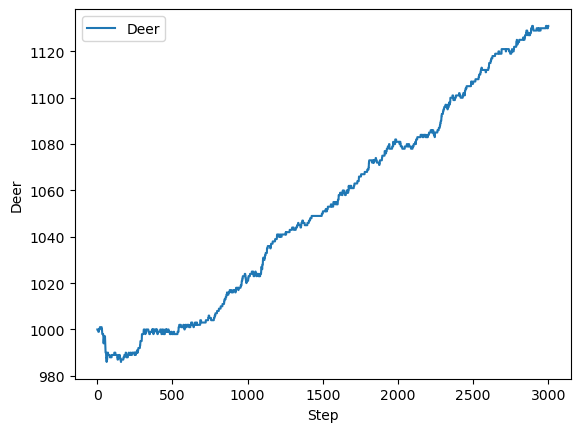

In [55]:
sns.lineplot(data=loads_results_df, x='Step', y='Deer', label='Deer')

<Axes: xlabel='Step', ylabel='Wolf'>

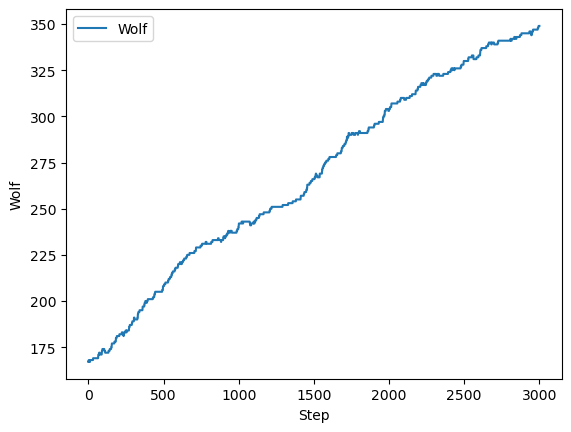

In [56]:
sns.lineplot(data=loads_results_df, x='Step', y='Wolf', label='Wolf')

<Axes: xlabel='Step', ylabel='Deer Hunted'>

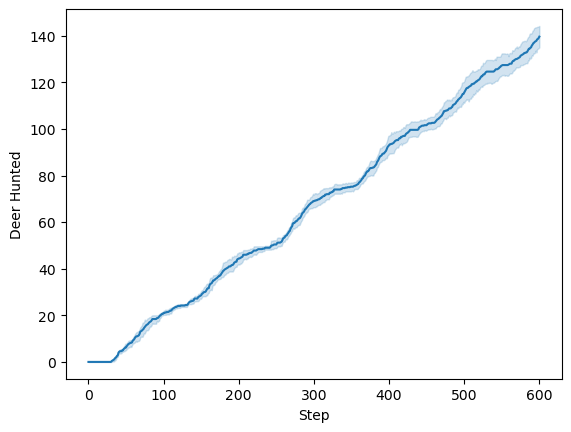

In [53]:
sns.lineplot(data=loads_results_df, x='Step', y='Deer Hunted')


### Many changed params

In [10]:
max_steps = 1000
new_params = {
            "max_steps": max_steps,
            "data_collection_period": 1, # collect data every 200 steps
            "init_predators": 15,  
            "init_deer": 1000,  # approx 10 deer per km^2 (1000 deer)
            "height": 10,
            "width": 10,
            "step_size": 0.25, # 15 min per step
            # yearly_sunlight_hours = 8760,
            "yearly_sunlight_hours": 5000,  # represents the fact that the agents are not active for all hours of the year (e.g. not active at night, less active in winter, etc.)

            "seed": None,
            "predator": 'Wolf',  # Helper attribute to avoid imports when accessing agent type
            "energy_decrease": 0.002,  # Energy decrease parameter 
            "pack_limit": 12,  # packs will split if too large 

            # Vegetation Parameters
            # "veg_patch_spacing": 4,
            # "sapling_density": 20,
            # "tree_density": 8,
            # "sapling_regrowth_prob": 1/10, # every 10 steps (10 hours) new sapling grows
            # "sapling_maturation_prob": 1/20000, # sapling becomes a tree every 20000 hours (2.3 years)

            # Options to control complexity of the model
            "use_base": False,
            "use_pack_dynamics": True,
            "use_random_movement": False,
            "use_veg": False,
            "given_positions": False, # whether to use random positions or pre-chosen positions (for testing purposes)
            "use_boundary_conditions": True, # whether to use boundary conditions (reflecting off walls) or toroidal space
}

n_iter = 1
# Creating batch runner to extract results.
new_results = mesa.batch_run(
    SpeciesModel,
    parameters=new_params,
    max_steps=max_steps,
    rng = [None] * n_iter,  # use random seed for n_iter iterations
    display_progress=True,
    number_processes = 20,
    data_collection_period = new_params["data_collection_period"]

)
# Extract results
new_results_df2 = pd.DataFrame(new_results)



  0%|          | 0/1 [00:00<?, ?it/s]

<Axes: xlabel='Step', ylabel='Deer'>

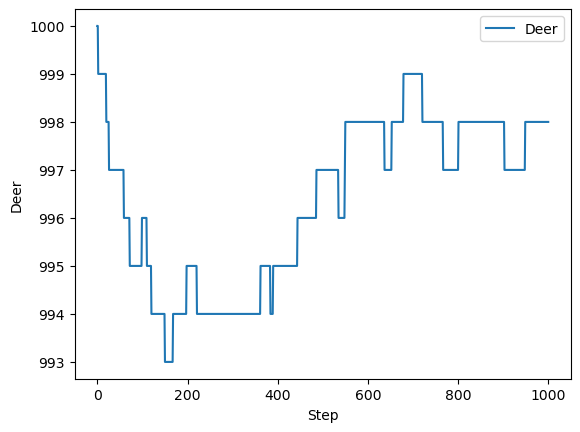

In [11]:
sns.lineplot(data=new_results_df2, x='Step', y='Deer', label='Deer')



<Axes: xlabel='Step', ylabel='Wolf'>

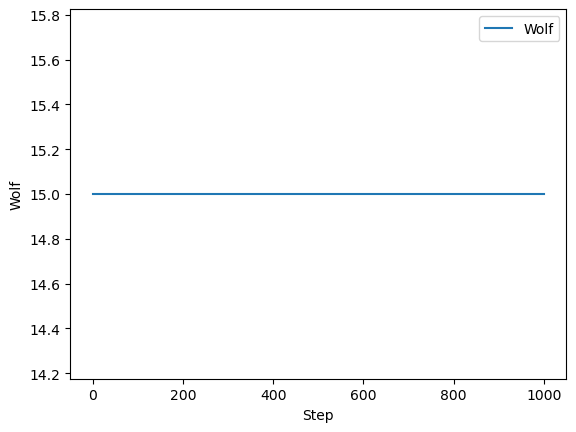

In [12]:
sns.lineplot(data=new_results_df2, x='Step', y='Wolf', label='Wolf')


<Axes: xlabel='Step', ylabel='Deer Hunted'>

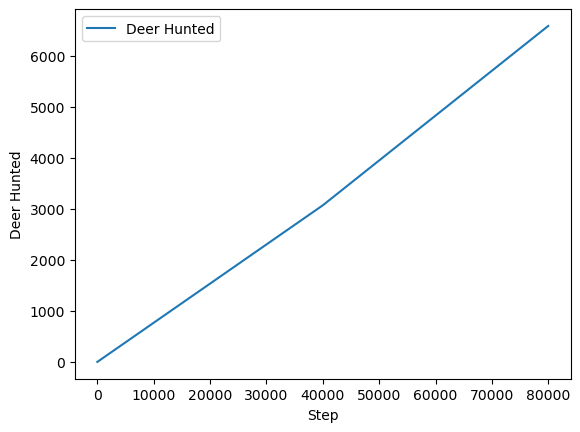

In [5]:
sns.lineplot(data=new_results_df2, x='Step', y='Deer Hunted', label='Deer Hunted')

In [13]:
sns.lineplot(data=new_results_df, x='Step', y='Deer', label='Deer')

NameError: name 'new_results_df' is not defined

<Axes: xlabel='Step', ylabel='Wolf'>

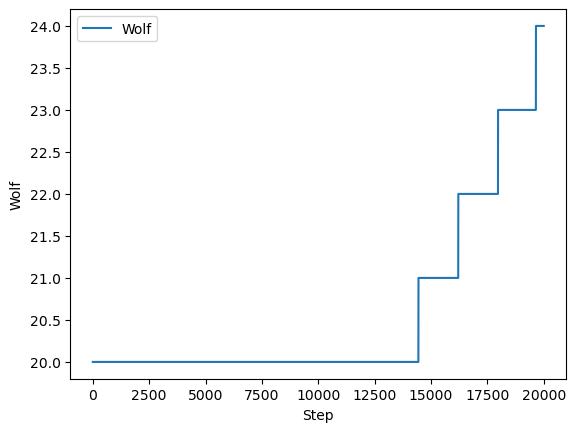

In [12]:
sns.lineplot(data=new_results_df, x='Step', y='Wolf', label='Wolf')


In [14]:
sns.lineplot(data=new_results_df, x='Step', y='Deer Hunted', label='Deer Hunted')

NameError: name 'new_results_df' is not defined

In [11]:
"""
Parameter sweep for Scottish wolf reintroduction scenario.
Optimised for i7-13700 (24 threads).
"""
from mesa import batch_run
from Model import SpeciesModel
import pandas as pd
import time

# ============================================================
# PHASE 1: Coarse sweep (step_size=1.0, ~10 year runs)
# ============================================================
print("=" * 60)
print("PHASE 1: Coarse parameter sweep")
print("=" * 60)

coarse_params = {
    "init_predators": [10, 15, 20, 30, 40],
    "init_deer": [1000],
    "max_steps": [50_000],        # ~10 years at step_size=1.0
    "step_size": [1.0],
    "energy_decrease": [0.0005, 0.001, 0.002, 0.003],
    "seed": range(5),             # 5 replicates
    "use_base": [False],
    "use_veg": [False],
    "use_boundary_conditions": [True],
}

n_combos = 5 * 4 * 5  # 100 runs
print(f"Running {n_combos} simulations across 20 cores...")

start = time.time()

results = batch_run(
    SpeciesModel,
    parameters=coarse_params,
    iterations=1,
    max_steps=50_000,
    number_processes=20,
    data_collection_period=-1,
    display_progress=True,
)

elapsed = time.time() - start
print(f"Phase 1 complete in {elapsed/60:.1f} minutes")

df = pd.DataFrame(results)
df.to_csv("coarse_sweep_results.csv", index=False)

# Summarise
summary = df.groupby(
    ["init_predators", "energy_decrease"]
).agg(
    mean_deer=("Deer", "mean"),
    std_deer=("Deer", "std"),
    mean_wolves=("Wolf", "mean"),
    std_wolves=("Wolf", "std"),
    extinctions=("Deer", lambda x: (x == 0).sum()),
).reset_index()

# Target: ~300 deer (3/km² × 100km²)
summary["distance_from_target"] = abs(summary["mean_deer"] - 300)
summary = summary.sort_values("distance_from_target")

print("\n" + "=" * 60)
print("TOP 10 PARAMETER COMBINATIONS (closest to 300 deer)")
print("=" * 60)
print(summary.head(10).to_string(index=False))

# ============================================================
# PHASE 2: Fine sweep around best parameters
# ============================================================
best = summary.iloc[0]
best_pred = int(best["init_predators"])
best_energy = float(best["energy_decrease"])

print(f"\nBest coarse params: pred={best_pred}, energy_dec={best_energy}")
print("Running fine sweep around these values...")

fine_params = {
    "init_predators": [max(5, best_pred - 5), best_pred, best_pred + 5],
    "init_deer": [1000],
    "max_steps": [200_000],       # ~10 years at step_size=0.25
    "step_size": [0.25],          # Full resolution
    "energy_decrease": [
        best_energy * 0.75,
        best_energy,
        best_energy * 1.25,
    ],
    "seed": range(10),            # More replicates for confidence
    "use_base": [False],
    "use_veg": [False],
    "use_boundary_conditions": [True],
}

n_fine = 3 * 3 * 10  # 90 runs
print(f"Running {n_fine} fine simulations...")

start = time.time()

fine_results = batch_run(
    SpeciesModel,
    parameters=fine_params,
    iterations=1,
    max_steps=200_000,
    number_processes=20,
    data_collection_period=1000,  # Collect every 1000 steps for time series
    display_progress=True,
)

elapsed = time.time() - start
print(f"Phase 2 complete in {elapsed/60:.1f} minutes")

fine_df = pd.DataFrame(fine_results)
fine_df.to_csv("fine_sweep_results.csv", index=False)

fine_summary = fine_df.groupby(
    ["init_predators", "energy_decrease"]
).agg(
    mean_deer=("Deer", "mean"),
    std_deer=("Deer", "std"),
    mean_wolves=("Wolf", "mean"),
    extinctions=("Deer", lambda x: (x == 0).sum()),
).reset_index()

fine_summary["distance_from_target"] = abs(fine_summary["mean_deer"] - 300)
fine_summary = fine_summary.sort_values("distance_from_target")

print("\n" + "=" * 60)
print("FINE SWEEP RESULTS")
print("=" * 60)
print(fine_summary.to_string(index=False))

PHASE 1: Coarse parameter sweep
Running 100 simulations across 20 cores...


/tmp/ipykernel_960601/734507761.py:34: DeprecationWarning: The `iterations` keyword argument is deprecated. Use `rng` instead (e.g. `iterations=5` is equivalent to `rng=[None] * 5`). See https://mesa.readthedocs.io/latest/migration_guide.html#batch-run
  results = batch_run(


  0%|          | 0/100 [00:00<?, ?it/s]

Process SpawnPoolWorker-20:
Process SpawnPoolWorker-19:
Process SpawnPoolWorker-16:
Process SpawnPoolWorker-15:
Process SpawnPoolWorker-18:
Process SpawnPoolWorker-14:
Process SpawnPoolWorker-17:
Process SpawnPoolWorker-13:
Process SpawnPoolWorker-8:
Process SpawnPoolWorker-12:
Process SpawnPoolWorker-6:
Process SpawnPoolWorker-11:
Process SpawnPoolWorker-7:
Process SpawnPoolWorker-9:
Process SpawnPoolWorker-5:
Process SpawnPoolWorker-10:
Process SpawnPoolWorker-4:
Process SpawnPoolWorker-2:
Process SpawnPoolWorker-1:
Process SpawnPoolWorker-3:


KeyboardInterrupt: 